# 01 — Target construction

Builds the target variable from 15-minute OHLC data:
1. Load data in MetaTrader 5 export format
2. Compute the ATR and the TP/SL levels
3. Determine `first_hit` (TP, SL, or NC = neither touched) within a fixed horizon
4. Build the binary target, discarding NC bars
5. Report the distribution and save the processed dataset

In [1]:
# === Cell 1: Configuration ===
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
DATA_PATH = pathlib.Path('../data/USDJPY_15M.csv')
OUTPUT_DIR = pathlib.Path('../outputs/reports')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Target parameters
HORIZON = 18         # 18 bars of 15M = 4.5 hours
ATR_PERIOD = 50           # ~12.5 hours of market time
K_TP = 2.5            # ATR multiplier for the take-profit
K_SL = 2.5      # ATR multiplier for the stop-loss
TICK = 0.001            # tick size for USDJPY (3-decimal quotes)
TIE_POLICY = 'neutral'    # intrabar tie (TP and SL in the same bar) -> discard

# Time filters (hours to exclude, in the broker's server time as exported by MT5)
EXCLUDE_HOURS = [20, 21, 22, 23]  # 20-21: low liquidity (NC > 50%); 22-23: Friday close

print('Configuration loaded')
print(f'  Horizon:      {HORIZON} bars ({HORIZON*15} min = {HORIZON*15/60:.1f}h)')
print(f'  ATR period:   {ATR_PERIOD} bars')
print(f'  K_TP / K_SL:  {K_TP} / {K_SL}')
print(f'  Tie policy:   {TIE_POLICY}')
print(f'  Excl. hours:  {EXCLUDE_HOURS}')

Configuration loaded
  Horizon:      18 bars (270 min = 4.5h)
  ATR period:   50 bars
  K_TP / K_SL:  2.5 / 2.5
  Tie policy:   neutral
  Excl. hours:  [20, 21, 22, 23]


In [2]:
# === Cell 2: Load and clean the data ===
df = pd.read_csv(DATA_PATH, sep='\t')

# Rename MT5-format columns
rename_map = {
    '<DATE>': 'Date', '<TIME>': 'Time',
    '<OPEN>': 'Open', '<HIGH>': 'High',
    '<LOW>': 'Low', '<CLOSE>': 'Close',
    '<TICKVOL>': 'TickVol', '<VOL>': 'Vol',
    '<SPREAD>': 'Spread'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Build the datetime column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df = df.sort_values('Datetime').reset_index(drop=True)

# Convert to numeric
for c in ['Open', 'High', 'Low', 'Close', 'TickVol', 'Spread']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print(f'Data loaded: {len(df):,} rows')
print(f'  Date range:   {df["Datetime"].min()} → {df["Datetime"].max()}')
print(f'  Columns:      {df.columns.tolist()}')
df.head()

Data loaded: 99,976 rows
  Date range:   2022-05-20 05:30:00 → 2026-05-27 21:30:00
  Columns:      ['Date', 'Time', 'Open', 'High', 'Low', 'Close', 'TickVol', 'Vol', 'Spread', 'Datetime']


,Date,Time,Open,High,Low,Close,TickVol,Vol,Spread,Datetime
0,2022.05.20,05:30:00,127.991,127.998,127.832,127.846,1010,0,5,2022-05-20 05:30:00
1,2022.05.20,05:45:00,127.846,127.848,127.525,127.610,1771,0,5,2022-05-20 05:45:00
2,2022.05.20,06:00:00,127.608,127.707,127.560,127.673,1689,0,5,2022-05-20 06:00:00
3,2022.05.20,06:15:00,127.673,127.782,127.660,127.673,1332,0,5,2022-05-20 06:15:00
4,2022.05.20,06:30:00,127.677,127.709,127.589,127.652,1045,0,5,2022-05-20 06:30:00


In [3]:
# === Cell 3: ATR computation ===
# True Range = max(H-L, |H-C_prev|, |L-C_prev|)
df['prev_close'] = df['Close'].shift(1)
df['tr'] = np.maximum.reduce([
    df['High'] - df['Low'],
    (df['High'] - df['prev_close']).abs(),
    (df['Low'] - df['prev_close']).abs()
])

# ATR as the simple moving average of TR
df['atr'] = df['tr'].rolling(window=ATR_PERIOD, min_periods=ATR_PERIOD).mean()

# IMPORTANT: ex-ante = ATR as of the previous close, known when the current bar opens
df['atr_exante'] = df['atr'].shift(1)

# Drop helper columns
df.drop(columns=['prev_close', 'tr', 'atr'], inplace=True)

# Diagnostics
atr_coverage = df['atr_exante'].notna().mean()
atr_pct_avg = (df['atr_exante'] / df['Open']).mean() * 100

print(f'ATR computed')
print(f'  Coverage:        {atr_coverage:.1%} ({df["atr_exante"].notna().sum():,} bars)')
print(f'  Mean ATR:        {df["atr_exante"].mean():.6f}')
print(f'  Mean ATR/Open:   {atr_pct_avg:.4f}% (typical relative volatility)')
print(f'  Rows w/o ATR:    {df["atr_exante"].isna().sum()} (first {ATR_PERIOD+1} bars)')

ATR computed
  Coverage:        99.9% (99,925 bars)
  Mean ATR:        0.120090
  Mean ATR/Open:   0.0825% (typical relative volatility)
  Rows w/o ATR:    51 (first 51 bars)


In [4]:
# === Cell 4: TP and SL levels ===
# Price levels (defined for a LONG; for a SHORT the roles of TP and SL are mirrored)
df['tp_pct'] = (K_TP * df['atr_exante']) / df['Open']
df['sl_pct'] = (K_SL * df['atr_exante']) / df['Open']
df['tp_price'] = df['Open'] + K_TP * df['atr_exante']
df['sl_price'] = df['Open'] - K_SL * df['atr_exante']

# Transaction cost (spread as a fraction of price)
df['cost_pct'] = (df['Spread'] * TICK) / df['Open']

print(f'TP/SL levels computed')
print(f'  Mean TP%:        {df["tp_pct"].mean()*100:.4f}%')
print(f'  Mean SL%:        {df["sl_pct"].mean()*100:.4f}%')
print(f'  Mean cost%:      {df["cost_pct"].mean()*100:.4f}% (spread)')
print(f'  TP/cost ratio:   {(df["tp_pct"].mean() / df["cost_pct"].mean()):.1f}x')

TP/SL levels computed
  Mean TP%:        0.2062%
  Mean SL%:        0.2062%
  Mean cost%:      0.0048% (spread)
  TP/cost ratio:   43.3x


In [5]:
# === Cell 5: first_hit computation ===
def compute_first_hit(df, horizon, tie_policy='neutral'):
    """
    For each bar i, scans the next `horizon` bars and returns:
      +1 if the TP is touched first
      -1 if the SL is touched first
       0 if neither is touched (NC), or on an intrabar tie when tie_policy='neutral'
    """
    H = df['High'].values
    L = df['Low'].values
    tp = df['tp_price'].values
    sl = df['sl_price'].values
    n = len(df)
    
    first_hit = np.zeros(n, dtype=np.int8)
    hit_offset = np.full(n, np.nan, dtype=float)
    ties = 0
    
    for i in range(n - horizon):
        if not (np.isfinite(tp[i]) and np.isfinite(sl[i])):
            first_hit[i] = -99  # flag for removal
            continue
        
        for k in range(1, horizon + 1):
            hi = H[i + k]
            lo = L[i + k]
            tp_hit = hi >= tp[i]
            sl_hit = lo <= sl[i]
            
            if tp_hit and sl_hit:
                ties += 1
                hit_offset[i] = k
                if tie_policy == 'tp':
                    first_hit[i] = 1
                elif tie_policy == 'sl':
                    first_hit[i] = -1
                else:  # neutral
                    first_hit[i] = 0
                break
            elif tp_hit:
                first_hit[i] = 1
                hit_offset[i] = k
                break
            elif sl_hit:
                first_hit[i] = -1
                hit_offset[i] = k
                break
    
    # Mark the last `horizon` bars as invalid (not enough future bars)
    first_hit[n-horizon:] = -99
    
    return first_hit, hit_offset, ties

fh, offset, ties = compute_first_hit(df, HORIZON, tie_policy=TIE_POLICY)
df['first_hit'] = fh
df['hit_offset'] = offset

# Drop invalid rows
valid = df['first_hit'] != -99
df_valid = df[valid].copy()

# Distribution
n_tp = (df_valid['first_hit'] == 1).sum()
n_sl = (df_valid['first_hit'] == -1).sum()
n_nc = (df_valid['first_hit'] == 0).sum()
n_total = len(df_valid)

print(f'first_hit computed on {n_total:,} valid bars')
print(f'  Intrabar ties:     {ties:,} ({ties/n_total*100:.2f}%)')
print()
print(f'first_hit distribution:')
print(f'  TP  (+1): {n_tp:>6,}  ({n_tp/n_total*100:5.2f}%)')
print(f'  SL  (-1): {n_sl:>6,}  ({n_sl/n_total*100:5.2f}%)')
print(f'  NC  ( 0): {n_nc:>6,}  ({n_nc/n_total*100:5.2f}%)  ← includes {ties} ties')
print()
print(f'Offset of the first hit (in bars):')
print(df_valid[df_valid['first_hit'] != 0]['hit_offset'].describe())

first_hit computed on 99,907 valid bars
  Intrabar ties:     629 (0.63%)

first_hit distribution:
  TP  (+1): 32,666  (32.70%)
  SL  (-1): 33,203  (33.23%)
  NC  ( 0): 34,038  (34.07%)  ← includes 629 ties

Offset of the first hit (in bars):
count    65869.000000
mean         7.904659
std          4.937862
min          1.000000
25%          4.000000
50%          7.000000
75%         12.000000
max         18.000000
Name: hit_offset, dtype: float64


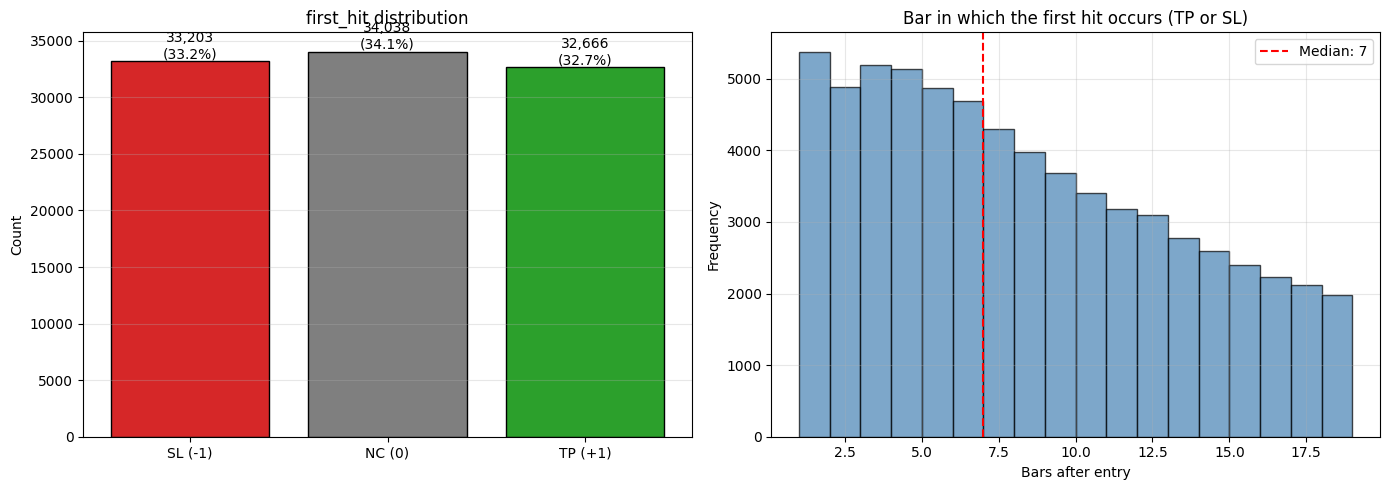


Saved: ../outputs/reports/target_distribution.png


In [6]:
# === Cell 6: Distribution plots ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# first_hit distribution
labels = ['SL (-1)', 'NC (0)', 'TP (+1)']
counts = [n_sl, n_nc, n_tp]
colors = ['#d62728', '#7f7f7f', '#2ca02c']
axes[0].bar(labels, counts, color=colors, edgecolor='black')
for i, c in enumerate(counts):
    axes[0].text(i, c, f'{c:,}\n({c/n_total*100:.1f}%)', ha='center', va='bottom')
axes[0].set_title('first_hit distribution')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Histogram of the offset (when the hit happened)
offsets_valid = df_valid[df_valid['first_hit'] != 0]['hit_offset']
axes[1].hist(offsets_valid, bins=range(1, HORIZON+2), color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(offsets_valid.median(), color='red', linestyle='--', label=f'Median: {offsets_valid.median():.0f}')
axes[1].set_title('Bar in which the first hit occurs (TP or SL)')
axes[1].set_xlabel('Bars after entry')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nSaved: {OUTPUT_DIR / "target_distribution.png"}')

In [7]:
# === Cell 7: Time filters ===
df_valid['hour'] = df_valid['Datetime'].dt.hour
df_valid['dayofweek'] = df_valid['Datetime'].dt.dayofweek

n_before = len(df_valid)

# Exclude low-liquidity hours
df_valid = df_valid[~df_valid['hour'].isin(EXCLUDE_HOURS)].copy()

n_after = len(df_valid)

print(f'Time filter applied')
print(f'  Rows before:  {n_before:,}')
print(f'  Rows after:   {n_after:,}  ({(n_before-n_after)/n_before*100:.1f}% removed)')
print()
print(f'Distribution by hour (after the filter):')
hourly = df_valid.groupby('hour')['first_hit'].agg(
    total='count',
    tp=lambda x: (x==1).sum(),
    sl=lambda x: (x==-1).sum(),
    nc=lambda x: (x==0).sum()
)
hourly['tp_rate'] = hourly['tp'] / hourly['total']
hourly['sl_rate'] = hourly['sl'] / hourly['total']
print(hourly)

Time filter applied
  Rows before:  99,907
  Rows after:   83,276  (16.6% removed)

Distribution by hour (after the filter):
      total    tp    sl    nc   tp_rate   sl_rate
hour                                             
0      4164  1493  1529  1142  0.358549  0.367195
1      4164  1414  1538  1212  0.339577  0.369356
2      4164  1315  1333  1516  0.315802  0.320125
3      4164  1296  1154  1714  0.311239  0.277137
4      4164  1415  1342  1407  0.339817  0.322286
5      4164  1660  1561   943  0.398655  0.374880
6      4164  1752  1716   696  0.420749  0.412104
7      4164  1729  1785   650  0.415226  0.428674
8      4164  1736  1657   771  0.416907  0.397935
9      4164  1621  1533  1010  0.389289  0.368156
10     4164  1663  1609   892  0.399376  0.386407
11     4164  1665  1653   846  0.399856  0.396974
12     4164  1710  1793   661  0.410663  0.430596
13     4164  1695  1803   666  0.407061  0.432997
14     4164  1695  1717   752  0.407061  0.412344
15     4164  1624  1547  

In [8]:
# === Cell 8: Binary target (Option A: drop NC) ===
# Target: 1 if the TP is touched first, 0 if the SL is touched first
# NC bars are excluded from training

df_target = df_valid[df_valid['first_hit'] != 0].copy()
df_target['target'] = (df_target['first_hit'] == 1).astype(int)

n_pos = (df_target['target'] == 1).sum()
n_neg = (df_target['target'] == 0).sum()

print(f'Binary target built (Option A: NC excluded)')
print(f'  Final rows:       {len(df_target):,}')
print(f'  Target = 1 (TP):  {n_pos:,}  ({n_pos/len(df_target)*100:.2f}%)')
print(f'  Target = 0 (SL):  {n_neg:,}  ({n_neg/len(df_target)*100:.2f}%)')
print()
print(f'  Balance: {min(n_pos, n_neg)/max(n_pos, n_neg)*100:.1f}% (ideally >80% for a balanced classification)')

# Sanity check: with K_TP = K_SL, a random-walk market would give ~50/50
# Any significant deviation points to market drift over the period
if abs(n_pos - n_neg) / len(df_target) > 0.05:
    direction = 'upward' if n_pos > n_neg else 'downward'
    print(f'\n  Warning: {direction} drift detected over the period')

Binary target built (Option A: NC excluded)
  Final rows:       57,345
  Target = 1 (TP):  28,783  (50.19%)
  Target = 0 (SL):  28,562  (49.81%)

  Balance: 99.2% (ideally >80% for a balanced classification)


In [9]:
# === Cell 9: Final summary and save ===
# Columns kept for the following notebooks
cols_keep = [
    'Datetime', 'Date', 'Time', 'hour', 'dayofweek',
    'Open', 'High', 'Low', 'Close', 'TickVol', 'Spread',
    'atr_exante', 'tp_pct', 'sl_pct', 'tp_price', 'sl_price', 'cost_pct',
    'first_hit', 'hit_offset', 'target'
]
df_final = df_target[cols_keep].reset_index(drop=True)

# Save
output_path = pathlib.Path('../data/USDJPY_15M_target.parquet')
df_final.to_parquet(output_path, index=False)

print(f'Processed dataset saved')
print(f'  File:         {output_path}')
print(f'  Rows:         {len(df_final):,}')
print(f'  Columns:      {len(df_final.columns)}')
print(f'  Period:       {df_final["Datetime"].min()} → {df_final["Datetime"].max()}')
print()
print('=== PIPELINE SUMMARY ===')
print(f'  Raw bars:            {len(df):,}')
print(f'  After ATR:           {df["atr_exante"].notna().sum():,}')
print(f'  After first_hit:     {n_total:,}')
print(f'  After hour filter:   {n_after:,}')
print(f'  After NC filter:     {len(df_final):,}  ← target ready')

Processed dataset saved
  File:         ../data/USDJPY_15M_target.parquet
  Rows:         57,345
  Columns:      20
  Period:       2022-05-20 19:30:00 → 2026-05-27 16:45:00

=== PIPELINE SUMMARY ===
  Raw bars:            99,976
  After ATR:           99,925
  After first_hit:     99,907
  After hour filter:   83,276
  After NC filter:     57,345  ← target ready
